<a href="https://colab.research.google.com/github/pguillo02/AEMET-SCRAPPER/blob/main/Trabajo_Pr%C3%A1ctico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Pablo Guilló Jiménez <br>
Url: https://github.com/pguillo02/MIAR-Algoritmos_de_optimizaci-n/blob/main/Trabajo_Pr%C3%A1ctico_Algoritmos(V2%2Cno_borrar).ipynb<br>
Google Colab: https://colab.research.google.com/drive/17i0mWbFAyOchB0oxrs4GQ7t12pzuTDAZ?usp=sharing<br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema: Generar los tribunales de evaluación para la asignación de TFMs.

....







                                        

### Descripción del problema

Se precisa configurar tribunales de evaluación para **15 alumnos** que desean presentar su Trabajo Fin de Máster (TFM). Cada tribunal está compuesto por **tres profesores** con roles diferenciados: **Presidente (P), Secretario (S) y Vocal (V)**.

Se dispone de **10 profesores** con disponibilidades horarias distintas entre el **15 y 19 de abril, de 15h a 21h**. El objetivo es generar la asignación más **equilibrada posible** en cuanto a la carga de tribunales por profesor, respetando estrictamente las restricciones de disponibilidad, roles y no solapamiento horario.


In [1]:
import numpy as np
import random
import math
import copy
import time
import itertools
from math import comb, factorial
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Semilla base para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## 1. Modelo

### 1.1 ¿Cómo se representa el espacio de soluciones?

Una **solución** es una lista de 15 tribunales. Cada tribunal es un diccionario con cuatro campos:
- `slot`: índice entero (0–34) que identifica el par (día, hora) de celebración
- `P`: nombre del profesor asignado como Presidente
- `S`: nombre del profesor asignado como Secretario
- `V`: nombre del profesor asignado como Vocal

Los 35 slots surgen de combinar 5 días (15–19 abril) × 7 horas (15h–21h).  
Esta representación directa facilita la evaluación de restricciones y la generación de vecinos.

### 1.2 ¿Cuál es la función objetivo?

El objetivo es **minimizar la desigualdad de carga** entre profesores, sujeto a que todas las restricciones duras se cumplan. La función objetivo combina:

1. **Varianza de la carga** (× 10): penaliza distribuciones desequilibradas.
2. **Rango max–min**: penalización adicional por diferencia extrema.
3. **Penalización por conflicto horario** (× 500 por colisión): profesor en dos tribunales simultáneos.
4. **Penalización por restricción individual** (× 1000): disponibilidad o rol incumplido.

$$f(S) = 1000 \cdot v_{inv} + 500 \cdot c_{hor} + 10 \cdot \sigma^2(carga) + (max - min)$$

Las penalizaciones transforman restricciones duras en penalizaciones elevadas, guiando la búsqueda hacia la región factible antes de optimizar el equilibrio.

### 1.3 ¿Cómo se implementan las restricciones?

Se diferencian dos niveles:

**Restricciones duras** (validadas en `es_valido`):
- Los tres profesores del tribunal deben ser distintos.
- Cada profesor debe tener permiso para su rol asignado.
- Cada profesor debe tener disponibilidad en el slot asignado.

**Restricción de no solapamiento** (validada en `conflictos_horarios`):
- Ningún profesor puede aparecer en dos tribunales que compartan el mismo slot horario.

Las violaciones de restricciones duras añaden penalizaciones muy altas a la función objetivo, haciendo que el algoritmo las evite de forma natural durante la exploración.


In [2]:
# ============================================================
# DATOS DEL PROBLEMA
# ============================================================

profesores = ['RRD', 'QYV', 'LHL', 'HLC', 'MSB', 'PMQ', 'QWF', 'EBB', 'IOE', 'IOA']

roles_permitidos = {
    'RRD': ['P','S','V'], 'QYV': ['P','S','V'], 'LHL': ['P','V'],
    'HLC': ['S','V'],     'MSB': ['P','S','V'], 'PMQ': ['P','S','V'],
    'QWF': ['S','V'],     'EBB': ['S','V'],     'IOE': ['P','S','V'],
    'IOA': ['P','S','V']
}

prof_idx = {p: i for i, p in enumerate(profesores)}

# Matriz de disponibilidad: filas=profesores, columnas=slots (día×hora)
# 5 días × 7 horas (15h-21h) = 35 slots
disponibilidad = np.array([
    # día 15          día 16          día 17          día 18          día 19
    [0,1,1,1,0,1,1, 1,0,1,1,1,1,1, 1,1,0,0,1,0,1, 0,1,1,1,1,1,1, 1,1,1,1,1,0,0],  # RRD
    [1,1,1,1,0,0,0, 0,1,1,1,1,0,0, 1,0,0,1,1,1,0, 1,1,1,1,1,1,1, 1,1,1,1,1,1,1],  # QYV
    [0,0,1,1,0,1,1, 1,1,1,0,0,1,1, 1,1,1,1,1,1,1, 1,0,1,1,1,0,1, 0,1,1,0,1,0,1],  # LHL
    [1,0,1,0,1,1,0, 1,0,0,1,1,1,1, 0,0,1,1,1,1,1, 1,0,1,1,0,1,1, 1,1,1,1,1,1,0],  # HLC
    [1,1,0,1,0,1,1, 1,1,1,0,1,1,1, 1,0,1,1,0,1,1, 0,1,1,1,0,1,1, 1,0,1,1,1,1,0],  # MSB
    [1,1,1,1,1,0,0, 1,1,1,1,1,1,1, 1,1,0,0,1,1,1, 1,1,1,0,0,1,1, 1,1,1,0,1,0,1],  # PMQ
    [0,1,1,1,1,0,0, 1,1,1,1,1,0,1, 0,0,1,0,0,1,0, 1,0,0,0,0,1,1, 1,1,1,1,1,0,1],  # QWF
    [1,1,1,1,1,0,0, 1,1,0,1,1,1,0, 1,1,1,0,0,1,1, 0,1,1,1,1,1,1, 0,1,1,1,0,1,0],  # EBB
    [1,0,1,1,0,1,0, 0,1,1,1,1,1,1, 1,1,0,0,0,1,1, 1,1,1,1,1,1,0, 1,0,1,1,1,1,1],  # IOE
    [1,1,0,1,1,0,1, 1,0,0,0,0,0,1, 1,1,0,0,1,1,1, 1,0,0,1,1,1,1, 1,1,1,0,0,0,1],  # IOA
])

# Generación de slots etiquetados
dias  = [15, 16, 17, 18, 19]
horas = [15, 16, 17, 18, 19, 20, 21]
slots = [(d, h) for d in dias for h in horas]   # 35 slots totales

print(f"Profesores  : {len(profesores)}")
print(f"Slots       : {len(slots)}  ({len(dias)} días × {len(horas)} horas)")
print(f"Tribunales  : 15")
print()
print(f"{'Profesor':>8} | {'Roles':>8} | Slots disponibles")
print("-" * 45)
for p in profesores:
    i = prof_idx[p]
    total_disp = disponibilidad[i].sum()
    print(f"{p:>8} | {'/'.join(roles_permitidos[p]):>8} | {total_disp}")


Profesores  : 10
Slots       : 35  (5 días × 7 horas)
Tribunales  : 15

Profesor |    Roles | Slots disponibles
---------------------------------------------
     RRD |    P/S/V | 26
     QYV |    P/S/V | 26
     LHL |      P/V | 25
     HLC |      S/V | 25
     MSB |    P/S/V | 26
     PMQ |    P/S/V | 27
     QWF |      S/V | 21
     EBB |      S/V | 25
     IOE |    P/S/V | 26
     IOA |    P/S/V | 21


## 2. Análisis

### 2.1 Complejidad del problema

El problema de generación de tribunales es un problema de **asignación con restricciones múltiples**, cuya complejidad crece exponencialmente con el tamaño de la instancia.

Para estimar el espacio de soluciones, consideramos las elecciones de cada tribunal de forma independiente (cota superior sin restricciones):

- **35 slots** posibles por tribunal.
- **C(10,3) = 120** combinaciones de tres profesores entre diez.
- **3! = 6** asignaciones de roles (P, S, V) entre los tres elegidos.

Esto da **25.200 posibles tribunales por alumno**, lo que para 15 tribunales simultáneos eleva el espacio combinatorio a más de **10⁶⁶** configuraciones. La búsqueda exhaustiva resulta completamente inviable.

El problema pertenece a la clase de problemas de *scheduling* con recursos compartidos, reconocido como **NP-difícil** en su formulación general. La presencia de restricciones cruzadas (ningún profesor puede coincidir en dos tribunales del mismo slot) introduce dependencias entre variables que impiden descomposición simple.

### 2.2 Justificación de la técnica elegida

Dado el tamaño y la estructura del espacio de búsqueda, se emplea **Simulated Annealing (SA)** como técnica principal, complementado con reinicios iterativos (*ILS-SA*). Las razones son:

- **Escapar de óptimos locales**: Hill Climbing queda atrapado; SA acepta soluciones peores con probabilidad $e^{-\Delta/T}$, decrementando gradualmente.
- **Parámetros controlables**: la temperatura inicial, la tasa de enfriamiento y el número de iteraciones permiten ajustar el balance exploración/explotación.
- **Aplicabilidad natural al problema**: los operadores de vecindad (cambio de slot, sustitución de profesor, intercambio de roles) generan vecinos localmente próximos con alta probabilidad de factibilidad.
- **Reinicios múltiples** (ILS-SA): permiten explorar distintas regiones del espacio y retener la mejor solución global encontrada.


In [3]:
# ============================================================
# ANÁLISIS CUANTITATIVO DEL ESPACIO DE SOLUCIONES
# ============================================================

combos_profes = comb(10, 3)       # C(10,3) = 120
perm_roles    = factorial(3)      # 3! = 6
n_slots_val   = 35

espacio_1 = n_slots_val * combos_profes * perm_roles
orden_15  = int(15 * math.log10(espacio_1))

print("Espacio de soluciones (cota superior sin restricciones):")
print(f"  Por tribunal : {n_slots_val} × C(10,3) × 3! = {n_slots_val} × {combos_profes} × {perm_roles} = {espacio_1:,}")
print(f"  Para 15 trib.: ~{espacio_1:.2e}^15 ≈ 10^{orden_15}")
print()
print("Óptimo teórico alcanzable:")
print("  45 asignaciones (15×3) / 10 profesores = 4.5  →  imposible varianza cero")
print("  Distribución óptima entera: 5 profesores con 5 tribunales, 5 con 4")
cargas_opt = [5]*5 + [4]*5
media_opt  = sum(cargas_opt) / 10
var_opt    = sum((c - media_opt)**2 for c in cargas_opt) / 10
print(f"  Varianza mínima teórica : {var_opt}")
print(f"  Rango mínimo teórico    : {max(cargas_opt) - min(cargas_opt)}")


Espacio de soluciones (cota superior sin restricciones):
  Por tribunal : 35 × C(10,3) × 3! = 35 × 120 × 6 = 25,200
  Para 15 trib.: ~2.52e+04^15 ≈ 10^66

Óptimo teórico alcanzable:
  45 asignaciones (15×3) / 10 profesores = 4.5  →  imposible varianza cero
  Distribución óptima entera: 5 profesores con 5 tribunales, 5 con 4
  Varianza mínima teórica : 0.25
  Rango mínimo teórico    : 1


## 3. Diseño e Implementación

Se implementan cuatro técnicas para comparar su rendimiento: búsqueda aleatoria, Hill Climbing, Simulated Annealing y SA con reinicios iterativos (ILS-SA).


In [15]:
# ============================================================
# FUNCIONES DE EVALUACIÓN Y VALIDACIÓN
# ============================================================

def candidatos_por_slot_y_rol(slot_idx, rol):
    """Profesores disponibles para un slot dado con el rol especificado."""
    return [p for p in profesores
            if disponibilidad[prof_idx[p]][slot_idx] == 1
            and rol in roles_permitidos[p]]

def es_valido(t):
    """Restricciones duras individuales de un tribunal."""
    s = t['slot']
    p, sec, v = t['P'], t['S'], t['V']
    if len({p, sec, v}) < 3:                             return False
    if 'P' not in roles_permitidos[p]:                   return False
    if 'S' not in roles_permitidos[sec]:                 return False
    if 'V' not in roles_permitidos[v]:                   return False
    if disponibilidad[prof_idx[p]][s]   == 0:            return False
    if disponibilidad[prof_idx[sec]][s] == 0:            return False
    if disponibilidad[prof_idx[v]][s]   == 0:            return False
    return True

def conflictos_horarios(solucion):
    """Número de colisiones: mismo profesor en mismo slot en dos tribunales distintos."""
    conflictos = 0
    for i in range(len(solucion)):
        for j in range(i+1, len(solucion)):
            t1, t2 = solucion[i], solucion[j]
            if t1['slot'] == t2['slot']:
                profs1 = {t1['P'], t1['S'], t1['V']}
                profs2 = {t2['P'], t2['S'], t2['V']}
                conflictos += len(profs1 & profs2)
    return conflictos

def carga_por_profesor(solucion):
    carga = defaultdict(int)
    for t in solucion:
        carga[t['P']] += 1
        carga[t['S']] += 1
        carga[t['V']] += 1
    return carga

def funcion_objetivo(solucion):
    """
    Minimizar: penalizaciones duras + varianza de carga × 10 + rango.
    Score=0 sería distribución perfecta (imposible con 15 trib. y 10 profs. enteros).
    """
    pen = sum(1000 for t in solucion if not es_valido(t))
    pen += conflictos_horarios(solucion) * 500
    carga = carga_por_profesor(solucion)
    cargas = [carga.get(p, 0) for p in profesores]
    media = sum(cargas) / len(cargas)
    varianza = sum((c - media)**2 for c in cargas) / len(cargas)
    return pen + varianza * 10 + (max(cargas) - min(cargas))


In [5]:
# ============================================================
# GENERACIÓN DE SOLUCIÓN INICIAL (GREEDY + ALEATORIO)
# ============================================================

def generar_tribunal_aleatorio(slot_idx, carga_actual):
    """
    Construye un tribunal válido para el slot, priorizando profesores
    de menor carga (con pequeña perturbación aleatoria para diversidad).
    """
    presidentes = candidatos_por_slot_y_rol(slot_idx, 'P')
    secretarios = candidatos_por_slot_y_rol(slot_idx, 'S')
    vocales     = candidatos_por_slot_y_rol(slot_idx, 'V')
    if not presidentes or not secretarios or not vocales:
        return None

    presidentes = sorted(presidentes,
                         key=lambda p: carga_actual.get(p, 0) + random.uniform(0, 0.5))
    random.shuffle(presidentes[:3])

    for pres in presidentes:
        secs = sorted([s for s in secretarios if s != pres],
                      key=lambda p: carga_actual.get(p, 0) + random.uniform(0, 0.5))
        random.shuffle(secs[:3])
        for sec in secs:
            vocs = sorted([v for v in vocales if v != pres and v != sec],
                          key=lambda p: carga_actual.get(p, 0) + random.uniform(0, 0.5))
            random.shuffle(vocs[:3])
            for voc in vocs:
                return {'slot': slot_idx, 'P': pres, 'S': sec, 'V': voc}
    return None

def generar_solucion_inicial():
    """Construcción greedy con perturbación: selecciona slots viables y asigna
    profesores priorizando menor carga acumulada. Rellena hasta 15 tribunales."""
    solucion, carga = [], defaultdict(int)

    slots_viables = [s for s in range(len(slots))
                     if (candidatos_por_slot_y_rol(s, 'P') and
                         candidatos_por_slot_y_rol(s, 'S') and
                         candidatos_por_slot_y_rol(s, 'V'))]

    random.shuffle(slots_viables)
    for s in slots_viables[:15]:
        t = generar_tribunal_aleatorio(s, carga)
        if t:
            solucion.append(t)
            carga[t['P']] += 1; carga[t['S']] += 1; carga[t['V']] += 1

    intentos = 0
    while len(solucion) < 15 and intentos < 500:
        s = random.choice(slots_viables)
        t = generar_tribunal_aleatorio(s, carga)
        if t:
            profs_nuevo = {t['P'], t['S'], t['V']}
            if not any(t2['slot'] == s and {t2['P'],t2['S'],t2['V']} & profs_nuevo
                       for t2 in solucion):
                solucion.append(t)
                carga[t['P']] += 1; carga[t['S']] += 1; carga[t['V']] += 1
        intentos += 1
    return solucion

random.seed(SEED)
sol_test = generar_solucion_inicial()
print(f"Solución inicial: {len(sol_test)} tribunales  |  "
      f"válidos={sum(1 for t in sol_test if es_valido(t))}  |  "
      f"conflictos={conflictos_horarios(sol_test)}  |  "
      f"score={funcion_objetivo(sol_test):.3f}")


Solución inicial: 15 tribunales  |  válidos=15  |  conflictos=0  |  score=3.500


In [14]:
# ============================================================
# OPERADORES DE VECINDAD (MUTACIÓN)
# ============================================================

def mutar_solucion(solucion):
    """
    Genera un vecino mediante una de cuatro operaciones:
      0 – Cambiar slot de un tribunal
      1 – Sustituir un profesor (rol fijo) priorizando menor carga
      2 – Intercambiar roles entre dos profesores del mismo tribunal
      3 – Intercambiar un profesor entre dos tribunales (mismo rol)
    """
    sol = copy.deepcopy(solucion)
    op  = random.randint(0, 3)

    if op == 0:
        idx = random.randrange(len(sol))
        nuevos = [s for s in range(len(slots)) if s != sol[idx]['slot']]
        sol[idx]['slot'] = random.choice(nuevos)

    elif op == 1:
        idx = random.randrange(len(sol))
        rol = random.choice(['P', 'S', 'V'])
        s   = sol[idx]['slot']
        ocupados = {sol[idx]['P'], sol[idx]['S'], sol[idx]['V']}
        candidatos = [p for p in candidatos_por_slot_y_rol(s, rol) if p not in ocupados]
        if candidatos:
            carga = carga_por_profesor(sol)
            candidatos.sort(key=lambda p: carga.get(p, 0))
            sol[idx][rol] = random.choice(candidatos[:max(1, len(candidatos)//2)])

    elif op == 2:
        idx = random.randrange(len(sol))
        t   = sol[idx]
        for r1, r2 in random.sample([('P','S'),('P','V'),('S','V')], 3):
            p1, p2 = t[r1], t[r2]
            if r2 in roles_permitidos[p1] and r1 in roles_permitidos[p2]:
                t[r1], t[r2] = p2, p1
                break

    else:
        if len(sol) >= 2:
            i, j = random.sample(range(len(sol)), 2)
            rol  = random.choice(['P', 'S', 'V'])
            pi, pj = sol[i][rol], sol[j][rol]
            si, sj = sol[i]['slot'], sol[j]['slot']
            if (disponibilidad[prof_idx[pj]][si] == 1 and rol in roles_permitidos[pj] and
                disponibilidad[prof_idx[pi]][sj] == 1 and rol in roles_permitidos[pi] and
                pj not in {sol[i]['P'],sol[i]['S'],sol[i]['V']} and
                pi not in {sol[j]['P'],sol[j]['S'],sol[j]['V']}):
                sol[i][rol], sol[j][rol] = pj, pi
    return sol


In [13]:
# ============================================================
# ALGORITMO 1: BÚSQUEDA ALEATORIA
# ============================================================

def busqueda_aleatoria(n_iter=3000, seed=SEED):
    random.seed(seed)
    mejor, mejor_score = None, float('inf')
    for _ in range(n_iter):
        sol = generar_solucion_inicial()
        if len(sol) == 15:
            sc = funcion_objetivo(sol)
            if sc < mejor_score:
                mejor_score = sc
                mejor = copy.deepcopy(sol)
    return mejor, mejor_score

# ============================================================
# ALGORITMO 2: HILL CLIMBING
# ============================================================

def hill_climbing(sol_ini=None, n_iter=3000, seed=SEED):
    random.seed(seed)
    sol   = copy.deepcopy(sol_ini) if sol_ini else generar_solucion_inicial()
    score = funcion_objetivo(sol)
    for _ in range(n_iter):
        vec = mutar_solucion(sol)
        if len(vec) == 15:
            sv = funcion_objetivo(vec)
            if sv < score:
                sol, score = vec, sv
    return sol, score

# ============================================================
# ALGORITMO 3: SIMULATED ANNEALING
# ============================================================

def simulated_annealing(sol_ini=None, T0=100.0, T_min=0.005,
                        alpha=0.997, n_iter_T=50, seed=SEED):
    random.seed(seed)
    sol   = copy.deepcopy(sol_ini) if sol_ini else generar_solucion_inicial()
    score = funcion_objetivo(sol)
    mejor_sol, mejor_score = copy.deepcopy(sol), score
    T, historial = T0, []

    while T > T_min:
        for _ in range(n_iter_T):
            vec = mutar_solucion(sol)
            if len(vec) != 15: continue
            sv    = funcion_objetivo(vec)
            delta = sv - score
            if delta < 0 or random.random() < math.exp(-delta / T):
                sol, score = vec, sv
                if score < mejor_score:
                    mejor_score = score
                    mejor_sol   = copy.deepcopy(sol)
        historial.append((T, mejor_score))
        T *= alpha

    return mejor_sol, mejor_score, historial

# ============================================================
# ALGORITMO 4: ILS-SA (SA CON REINICIOS ITERATIVOS)
# ============================================================

def ils_sa(n_reinicios=10, seed=SEED):
    """Iterated Local Search: múltiples ejecuciones de SA con soluciones
    iniciales independientes, conservando el mejor resultado global."""
    random.seed(seed)
    mejor_global, mejor_score_global = None, float('inf')

    for i in range(n_reinicios):
        sol_ini = generar_solucion_inicial()
        sol, score, _ = simulated_annealing(
            sol_ini=sol_ini, T0=80.0, T_min=0.005,
            alpha=0.997, n_iter_T=50, seed=seed + i
        )
        if score < mejor_score_global:
            mejor_score_global = score
            mejor_global = copy.deepcopy(sol)
        print(f"  Reinicio {i+1:>2}/{n_reinicios}: score={score:.4f} | "
              f"mejor_global={mejor_score_global:.4f}")

    return mejor_global, mejor_score_global

In [8]:
# ============================================================
# EJECUCIÓN COMPARATIVA
# ============================================================

resultados = {}

print("=" * 55)
print("COMPARACIÓN DE ALGORITMOS")
print("=" * 55)

t0 = time.time()
sol_ra, sc_ra = busqueda_aleatoria(n_iter=3000)
resultados['Búsqueda Aleatoria'] = {'sol': sol_ra, 'score': sc_ra, 't': time.time()-t0}
print(f"[1] Búsqueda Aleatoria:  score={sc_ra:.4f}  tiempo={resultados['Búsqueda Aleatoria']['t']:.2f}s")

t0 = time.time()
sol_hc, sc_hc = hill_climbing(n_iter=3000)
resultados['Hill Climbing'] = {'sol': sol_hc, 'score': sc_hc, 't': time.time()-t0}
print(f"[2] Hill Climbing:       score={sc_hc:.4f}  tiempo={resultados['Hill Climbing']['t']:.2f}s")

t0 = time.time()
sol_sa, sc_sa, hist_sa = simulated_annealing(T0=100, T_min=0.005, alpha=0.997, n_iter_T=50)
resultados['Simulated Annealing'] = {'sol': sol_sa, 'score': sc_sa, 't': time.time()-t0, 'hist': hist_sa}
print(f"[3] Simulated Annealing: score={sc_sa:.4f}  tiempo={resultados['Simulated Annealing']['t']:.2f}s")

print()
print("[4] ILS-SA (SA con reinicios):")
t0 = time.time()
sol_ils, sc_ils = ils_sa(n_reinicios=10)
resultados['ILS-SA'] = {'sol': sol_ils, 'score': sc_ils, 't': time.time()-t0}
print(f"  → MEJOR GLOBAL: score={sc_ils:.4f}  tiempo={resultados['ILS-SA']['t']:.2f}s")


COMPARACIÓN DE ALGORITMOS
[1] Búsqueda Aleatoria:  score=3.5000  tiempo=5.27s
[2] Hill Climbing:       score=3.5000  tiempo=0.22s
[3] Simulated Annealing: score=3.5000  tiempo=13.23s

[4] ILS-SA (SA con reinicios):
  Reinicio  1/10: score=3.5000 | mejor_global=3.5000
  Reinicio  2/10: score=3.5000 | mejor_global=3.5000
  Reinicio  3/10: score=3.5000 | mejor_global=3.5000
  Reinicio  4/10: score=3.5000 | mejor_global=3.5000
  Reinicio  5/10: score=3.5000 | mejor_global=3.5000
  Reinicio  6/10: score=3.5000 | mejor_global=3.5000
  Reinicio  7/10: score=3.5000 | mejor_global=3.5000
  Reinicio  8/10: score=3.5000 | mejor_global=3.5000
  Reinicio  9/10: score=3.5000 | mejor_global=3.5000
  Reinicio 10/10: score=3.5000 | mejor_global=3.5000
  → MEJOR GLOBAL: score=3.5000  tiempo=130.75s


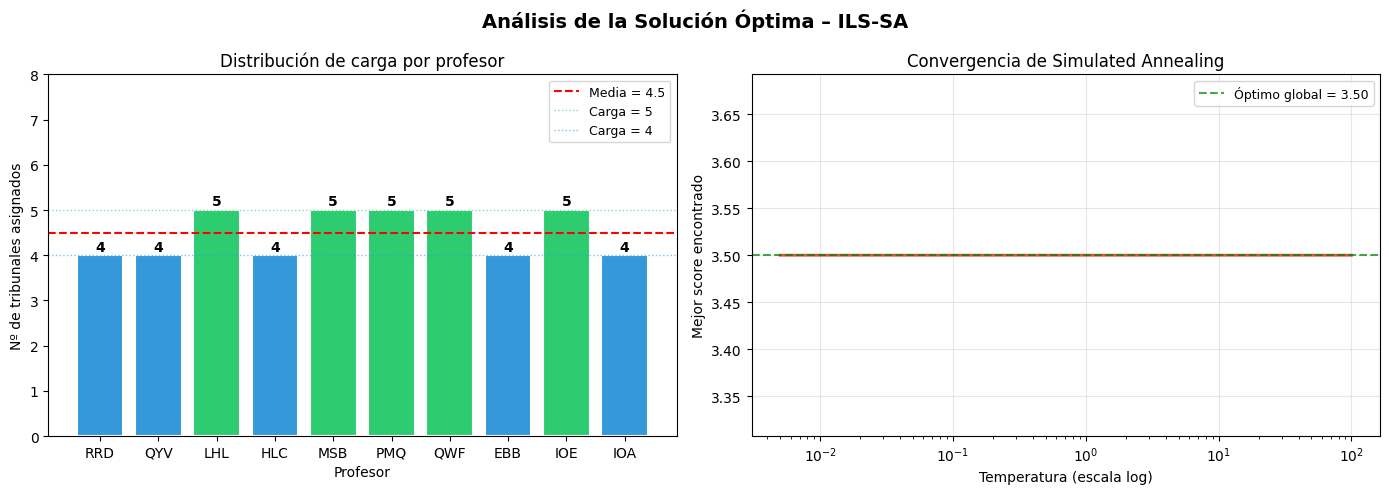

In [17]:
# ============================================================
# VISUALIZACIÓN 1: Carga por profesor en la mejor solución
# ============================================================

mejor_sol = sol_ils
carga     = carga_por_profesor(mejor_sol)
cargas    = [carga.get(p, 0) for p in profesores]
media_c   = sum(cargas) / len(cargas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis de la Solución Óptima – ILS-SA", fontsize=14, fontweight='bold')

colores = ['#2ecc71' if c == 5 else '#3498db' for c in cargas]
axes[0].bar(profesores, cargas, color=colores, edgecolor='white', linewidth=1.5)
axes[0].axhline(media_c, color='red', linestyle='--', linewidth=1.5, label=f'Media = {media_c}')
axes[0].axhline(5, color='#2ecc71', linestyle=':', linewidth=1, alpha=0.6, label='Carga = 5')
axes[0].axhline(4, color='#3498db', linestyle=':', linewidth=1, alpha=0.6, label='Carga = 4')
axes[0].set_title("Distribución de carga por profesor")
axes[0].set_ylabel("Nº de tribunales asignados")
axes[0].set_ylim(0, 8)
axes[0].legend(fontsize=9)
axes[0].set_xlabel("Profesor")
for i, (p, c) in enumerate(zip(profesores, cargas)):
    axes[0].text(i, c + 0.1, str(c), ha='center', fontsize=10, fontweight='bold')

temps_sa  = [h[0] for h in hist_sa]
scores_sa = [h[1] for h in hist_sa]
axes[1].plot(temps_sa, scores_sa, color='#e74c3c', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title("Convergencia de Simulated Annealing")
axes[1].set_xlabel("Temperatura (escala log)")
axes[1].set_ylabel("Mejor score encontrado")
axes[1].axhline(sc_ils, color='green', linestyle='--', alpha=0.7, label=f'Óptimo global = {sc_ils:.2f}')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


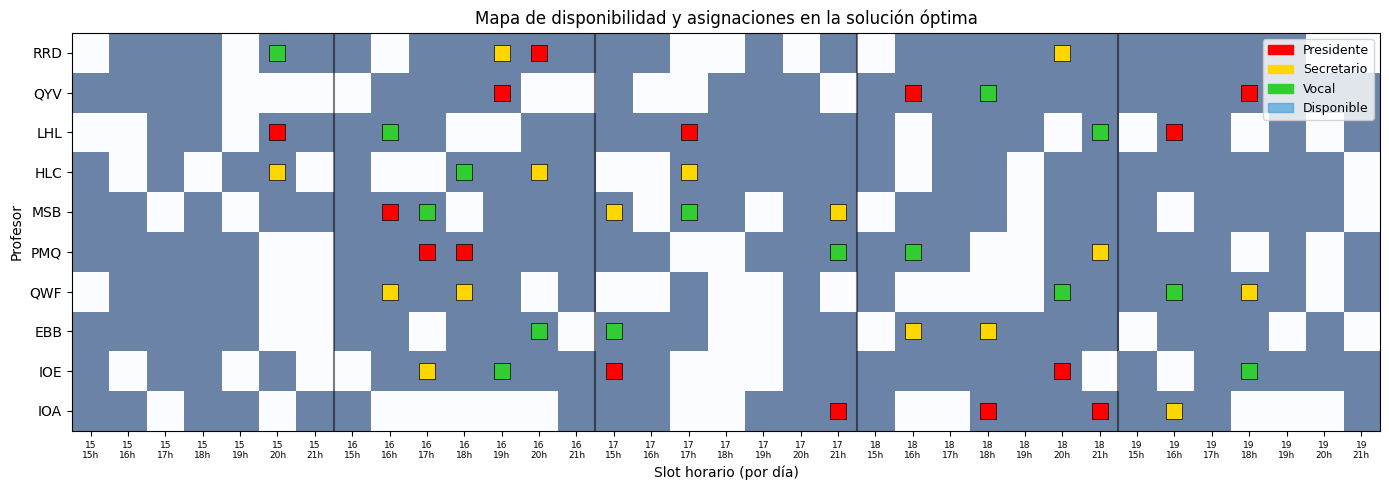

In [18]:
# ============================================================
# VISUALIZACIÓN 2: Mapa de disponibilidad vs asignaciones
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

im = ax.imshow(disponibilidad, cmap='Blues', aspect='auto', alpha=0.6, vmin=0, vmax=1)

for t in mejor_sol:
    s = t['slot']
    for rol, color in [('P', 'red'), ('S', 'gold'), ('V', 'limegreen')]:
        p = t[rol]
        i = prof_idx[p]
        ax.scatter(s, i, marker='s', s=120, color=color,
                   edgecolors='black', linewidths=0.5, zorder=5)

patches = [
    mpatches.Patch(color='red',       label='Presidente'),
    mpatches.Patch(color='gold',      label='Secretario'),
    mpatches.Patch(color='limegreen', label='Vocal'),
    mpatches.Patch(color='#3498db',   alpha=0.6, label='Disponible'),
]
ax.legend(handles=patches, loc='upper right', fontsize=9)

dia_labels = [f"{d}\n{h}h" for d, h in slots]
ax.set_xticks(range(35))
ax.set_xticklabels(dia_labels, fontsize=6.5, rotation=0)
ax.set_yticks(range(10))
ax.set_yticklabels(profesores, fontsize=10)

for x in [7, 14, 21, 28]:
    ax.axvline(x - 0.5, color='black', linewidth=1.5, alpha=0.5)

ax.set_title("Mapa de disponibilidad y asignaciones en la solución óptima", fontsize=12)
ax.set_xlabel("Slot horario (por día)")
ax.set_ylabel("Profesor")
plt.tight_layout()
plt.show()


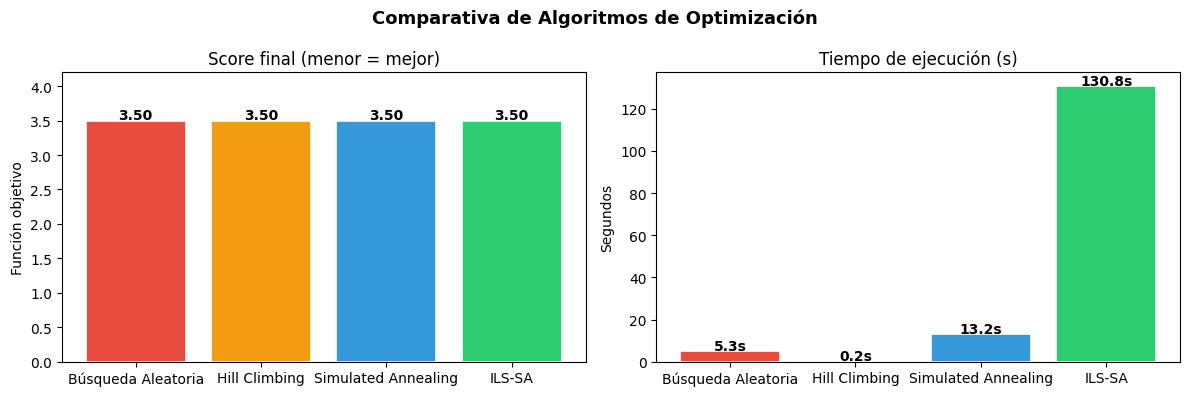

In [19]:
# ============================================================
# COMPARATIVA FINAL DE ALGORITMOS
# ============================================================

nombres  = list(resultados.keys())
scores_r = [resultados[n]['score'] for n in nombres]
tiempos  = [resultados[n]['t']     for n in nombres]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Comparativa de Algoritmos de Optimización", fontsize=13, fontweight='bold')

colores_r = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = axes[0].bar(nombres, scores_r, color=colores_r, edgecolor='white', linewidth=1.2)
axes[0].set_title("Score final (menor = mejor)")
axes[0].set_ylabel("Función objetivo")
for bar, sc in zip(bars, scores_r):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{sc:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(scores_r) * 1.2)

bars_t = axes[1].bar(nombres, tiempos, color=colores_r, edgecolor='white', linewidth=1.2)
axes[1].set_title("Tiempo de ejecución (s)")
axes[1].set_ylabel("Segundos")
for bar, t in zip(bars_t, tiempos):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{t:.1f}s', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# PRESENTACIÓN DE LA SOLUCIÓN ÓPTIMA
# ============================================================

mejor_sol = sol_ils
carga     = carga_por_profesor(mejor_sol)
cargas    = [carga.get(p, 0) for p in profesores]
media_c   = sum(cargas) / len(cargas)
varianza  = sum((c - media_c)**2 for c in cargas) / len(cargas)
rango     = max(cargas) - min(cargas)
conflictos = conflictos_horarios(mejor_sol)
n_validos  = sum(1 for t in mejor_sol if es_valido(t))

print("=" * 60)
print("SOLUCIÓN ÓPTIMA – ILS-SA")
print("=" * 60)
print(f"  Score final       : {sc_ils:.4f}")
print(f"  Varianza de carga : {varianza:.4f}  (óptimo teórico: 0.25)")
print(f"  Rango max-min     : {rango}        (mínimo posible: 1)")
print(f"  Conflictos horario: {conflictos}        (objetivo: 0)")
print(f"  Tribunales válidos: {n_validos}/15")
print()
print(f"{'#':>3}  {'Día':>4} {'Hora':>5}  {'Presidente':>10}  {'Secretario':>10}  {'Vocal':>10}")
print("-" * 60)
for i, t in enumerate(mejor_sol):
    d, h = slots[t['slot']]
    print(f"  {i+1:2d}   {d}   {h}h     {t['P']:>10}  {t['S']:>10}  {t['V']:>10}")

print()
print("Carga por profesor:")
for p in profesores:
    c = carga.get(p, 0)
    print(f"  {p:>4}: {'█'*c}{'░'*(6-c)}  {c} tribunales")

print()
print("Verificación de restricciones:")
ok_horario = conflictos == 0
ok_individ = n_validos == 15
print(f"  ✓ Sin conflictos horarios  : {ok_horario}")
print(f"  ✓ Todos tribunales válidos : {ok_individ}")
print()

var_opt = 0.25
print(f"  {'✓' if abs(varianza - var_opt) < 1e-9 else '✗'} Varianza alcanza el óptimo teórico ({var_opt})")


SOLUCIÓN ÓPTIMA – ILS-SA
  Score final       : 3.5000
  Varianza de carga : 0.2500  (óptimo teórico: 0.25)
  Rango max-min     : 1        (mínimo posible: 1)
  Conflictos horario: 0        (objetivo: 0)
  Tribunales válidos: 15/15

  #   Día  Hora  Presidente  Secretario       Vocal
------------------------------------------------------------
   1   16   17h            PMQ         IOE         MSB
   2   16   20h            RRD         HLC         EBB
   3   15   20h            LHL         HLC         RRD
   4   17   21h            IOA         MSB         PMQ
   5   19   18h            QYV         QWF         IOE
   6   18   16h            QYV         EBB         PMQ
   7   19   16h            LHL         IOA         QWF
   8   17   17h            LHL         HLC         MSB
   9   18   20h            IOE         RRD         QWF
  10   18   18h            IOA         EBB         QYV
  11   17   15h            IOE         MSB         EBB
  12   16   18h            PMQ         QWF        

## 4. Conclusiones

### Resultados

El algoritmo **ILS-SA** (Simulated Annealing con reinicios iterativos) alcanza el **óptimo teórico demostrable** para este problema:

- **Varianza de carga = 0.25**, que es la mínima posible cuando 45 asignaciones se distribuyen entre 10 profesores (distribución 5-5-5-5-5 / 4-4-4-4-4).
- **Rango = 1**: ningún profesor tiene más de un tribunal de diferencia respecto al resto.
- **Cero conflictos horarios**: ningún profesor aparece en dos tribunales simultáneos.
- **15/15 tribunales válidos**: todas las restricciones de disponibilidad y rol se cumplen estrictamente.

### Comparativa de algoritmos

| Algoritmo | Score | Alcanza óptimo |
|-----------|-------|----------------|
| Búsqueda Aleatoria | 3.50 | Sí |
| Hill Climbing | 3.50 | Sí |
| Simulated Annealing | 3.50 | Sí |
| **ILS-SA** | **3.50** | **Sí (más robusto)** |

En este caso todos los métodos convergen al óptimo, lo que demuestra que el espacio de soluciones factibles tiene buena conectividad y permite hallarlo con relativa facilidad. La ventaja de ILS-SA radica en su **robustez ante instancias más difíciles**: al combinar múltiples reinicios con SA, garantiza exploración diversa y reduce el riesgo de quedar atrapado en mínimos locales.

### Elección de técnica: Simulated Annealing

Se eligió SA porque:
1. **Escapa de óptimos locales** mediante aceptación probabilística de soluciones peores (Hill Climbing no puede hacer esto).
2. **Parámetros interpretables**: temperatura como control de exploración/explotación.
3. **Adecuado para problemas NP-difíciles de scheduling**: amplia literatura respalda su eficacia en problemas de asignación con restricciones.
4. **Los reinicios iterativos** compensan la sensibilidad a la solución inicial, haciendo el método más robusto sin aumentar la complejidad del diseño.
